##Final Project:##
**Dynamo Revit Data Extraction using CSV file and using Visualization with Python**

Objective: To develop visualizations that uses Dynamo to extract building characteristics from the steam services structural pre-made Revit model and export the data to a CSV file, which can then be uploaded to Google Colab to create various visualizations using Python.

Project Description: The aim of this project is to utilize Dynamo in Revit to extract valuable information from a given Revit model, such as square footage for walls and flooring, structural beam types, etc., and export that data to a CSV file. This data will then be imported into Google Colab for creating visualizations for reading using Python.

##1) Extract the element parameters from "Structural Framing" & "Structural Columns" categories and export it to excel files. Take a look how Dynamo formatted the data in excel and export the excel files to a CSV file type to upload here.##


For Dynamo, you need the following nodes: **Catergories**, **All Elements of Category**, **Element.Parameters**, **Data.ExportToExcel**, **File Path**, **String**, **Integer Silder**. You need create different blank excel files before exporting the data and set the file paths for Data.ExportToExcel to work properly. Use "Sheet1" for **sheetName**, and use "0" for **startRow**, **startColumn**.

For help exporting excel file to a CSV file, see the link here: https://knowledgebase.constantcontact.com/articles/KnowledgeBase/6409-saving-an-excel-file-as-a-csv-file?lang=en_US

For help uploading the files to this site see the link here: https://betterprogramming.pub/google-colab-dealing-with-files-49fce565c02d

If you have problems reading the CSV with pandas, try using this line of code: **data = pd.read_csv(csv_file, header=None,encoding='cp1252')**

**A) Make a bargraph to count the amount of different types of structural framing, please use proper coding practices and label all the graphs correctly as well.** Hint: Loop through every cell and find the "Family and Type :" text and store the text that follows in a list.

In [2]:
# import all libraries in advance
import requests
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
# reading file
url_framing = 'https://pennstateoffice365-my.sharepoint.com/:x:/g/personal/rjn5308_psu_edu/EWqG_s1iiAVCpckV58NqqjQBF7VQ5_G4KXWmQ_uyJBhU1g?e=sfKZdd'
url_framing = url_framing + '&download=1'
r = requests.get(url_framing)

r.status_code
with open('framing.csv', 'w') as fid:
    fid.write(r.text)

framing = pd.read_csv("framing.csv")
print("size df: ", len(framing))

# convert entire dataframe to string type
df_framing = framing.astype(str)

# extracting framing types
framing_types = []

for column in df_framing.columns:
    for cell in df_framing[column]:
        if "Family and Type :" in cell:
            family_type = cell.split("Family and Type :")[1].strip()
            framing_types.append(family_type)

print("size framing_types:", len(framing_types))

# using Counter() to count the framing types: https://www.geeksforgeeks.org/counters-in-python-set-1/
type_counts = Counter(framing_types)
print(type_counts)

print(type_counts.keys())  # unique types
print(type_counts.values())  # their corresponding values

# alternatively you can convert to Series/DataFrame to use value_counts() as learned in class
framing_series = pd.Series(framing_types)
# print(framing_series)

framing_series_counts = framing_series.value_counts()
# print("framing counts: ", framing_series_counts)


size df:  783
size framing_types: 783
Counter({'K-Series Bar Joist-Rod Web: 12K1': 164, 'K-Series Bar Joist-Rod Web: 16K3': 109, 'HSS-Hollow Structural Section: HSS2-1/2X2-1/2X5/16': 74, 'K-Series Bar Joist-Rod Web: 16K2': 66, 'K-Series Bar Joist-Rod Web: 18K9': 53, 'K-Series Bar Joist-Rod Web: 18K3': 40, 'W-Wide Flange: W16X26': 35, 'W-Wide Flange: W18X35': 35, 'K-Series Bar Joist-Rod Web: 20K4': 34, 'W-Wide Flange: W12X14': 25, 'W-Wide Flange: W18X46': 18, 'K-Series Bar Joist-Rod Web: 16K4': 18, 'W-Wide Flange: W12X19': 15, 'W-Wide Flange: W12X16': 12, 'W Shapes: W16X26': 10, 'W-Wide Flange: W21X55': 9, 'L-Angle: L4X4X3/8': 8, 'MC-Miscellaneous Channel: MC13X35': 8, 'W-Wide Flange: W16X31': 8, 'HSS Square: HSS6X6X1/2': 7, 'W-Wide Flange: W21X48': 5, 'W-Wide Flange: W21X44': 5, 'K-Series Bar Joist-Rod Web: 14K3': 5, 'W-Wide Flange: W18X50': 4, 'W-Wide Flange: W16X36': 4, 'W-Wide Flange: W18X40': 4, 'W-Wide Flange: W21X68': 2, 'W Shapes: W12X26': 1, 'W-Wide Flange: W8X18': 1, 'W-Wide F

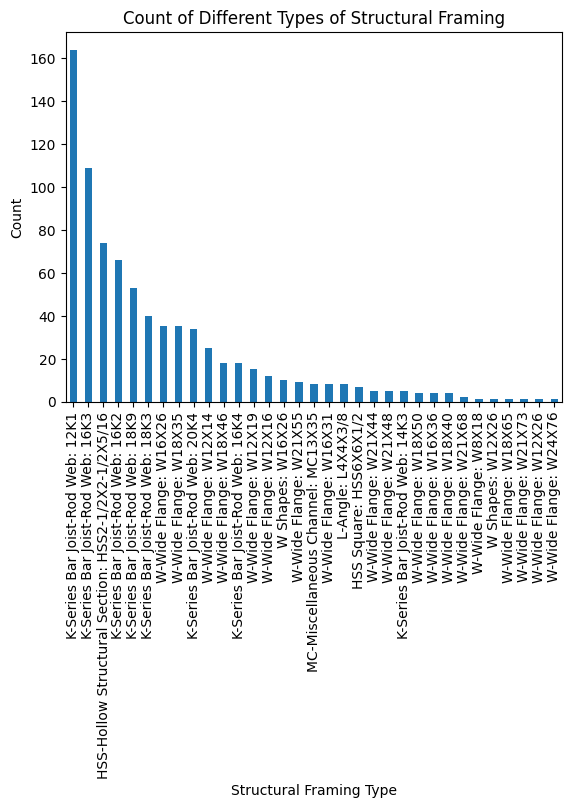

In [4]:
# Figure - option 1: plot bar chart based on framing_series_counts
framing_series_counts.plot(kind='bar')
plt.title('Count of Different Types of Structural Framing')
plt.xlabel('Structural Framing Type')
plt.ylabel('Count')
plt.show()

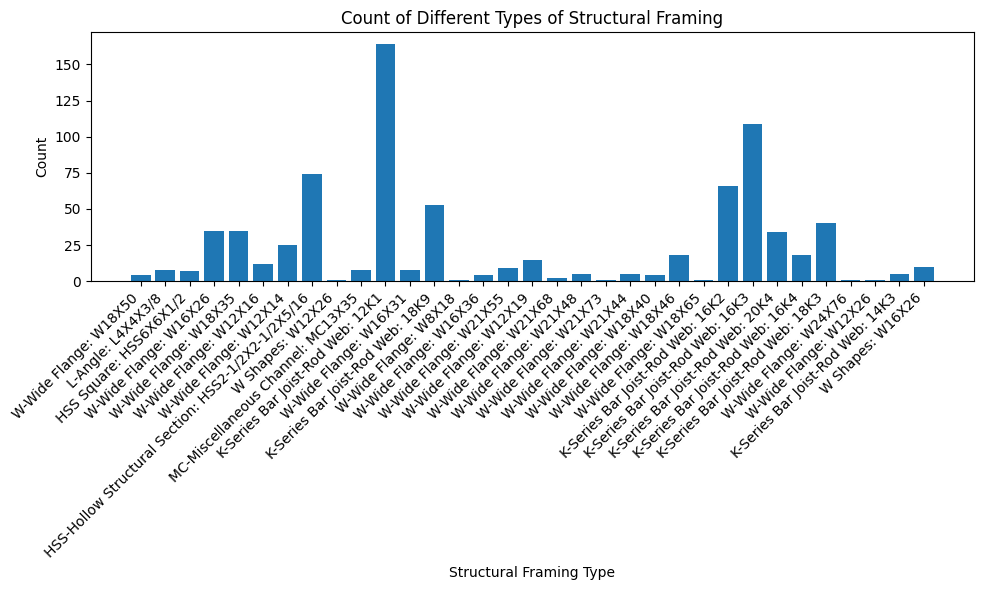

In [5]:
# Figure - Option 2: plot bar from type_counts
plt.figure(figsize=(10, 6))
plt.bar(type_counts.keys(), type_counts.values())
# add title and labels
plt.title('Count of Different Types of Structural Framing')
plt.xlabel('Structural Framing Type')
plt.ylabel('Count')
# rotate axes
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

**B) Make a bargraph to count the amount of different types of columns**

In [6]:
# reading file
url_column = 'https://pennstateoffice365-my.sharepoint.com/:x:/g/personal/rjn5308_psu_edu/EfN8F0LbQPdCj9BBpuljQ1MBTegWq8_bkvrD3knNRiN7Dw?e=gibvqD'
url_column = url_column + '&download=1'
r = requests.get(url_column)

r.status_code
with open('column.csv', 'w') as fid:
    fid.write(r.text)

column = pd.read_csv("column.csv")
print("size df: ", len(column))

# convert entire dataframe to string type
df_column = column.astype(str)

# extracting framing types
columns_types = []

for cols in df_column.columns:
    for row in df_column[cols]:
        if "Family and Type :" in row:
            column_type = row.split("Family and Type :")[1].strip()
            columns_types.append(column_type)

print("size columns_types:", len(columns_types))

# alternatively you can convert to Series/DataFrame to use value_counts() as learned in class
columns_series = pd.Series(columns_types)
# print(columns_series)

columns_series_counts = columns_series.value_counts()
# print("columns counts: ", columns_series_counts)


size df:  85
size columns_types: 85


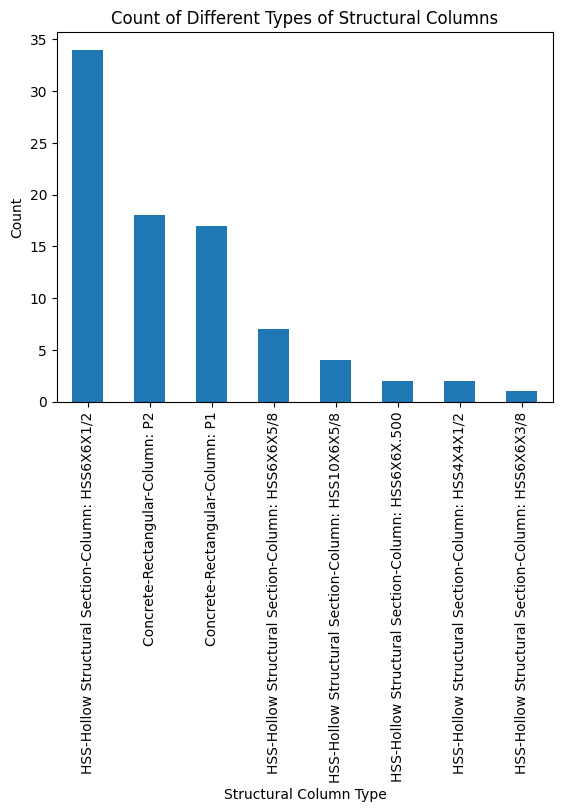

In [7]:
# Plot bar chart based on framing_series_counts
columns_series_counts.plot(kind='bar')
plt.title('Count of Different Types of Structural Columns')
plt.xlabel('Structural Column Type')
plt.ylabel('Count')
plt.show()

##2) Extract the element parameters from "Floors" & "Walls" categories and export it to excel files. Take a look how Dynamo formatted the data in excel and export the excel files to a CSV file type to upload here.##

**A) Make a pie chart to compare the amount of area per Floor.**

In [8]:
# reading file
url_floors = 'https://pennstateoffice365-my.sharepoint.com/:x:/g/personal/rjn5308_psu_edu/EZCu_kte5eFJttj5SAVugMkBhhmIqr94eRsPUYHtzXrE2w?e=FLIl2R'
url_floors = url_floors + '&download=1'
r = requests.get(url_floors)

r.status_code
with open('floors.csv', 'w') as fid:
    fid.write(r.text)

floors_df = pd.read_csv("floors.csv")
print("size floors: ", len(floors_df))

# convert entire dataframe to string type
df_floors = floors_df.astype(str)

# extracting framing types
areas = []

for column in df_floors.columns:
    for cell in df_floors[column]:
        if "Area :" in cell:
            area = cell.split("Area :")[1].strip()
            areas.append(area)

print("size areas:", len(areas))
print(areas)

# clean ' SF' and convert to float
areas_float = [float(area.replace('SF', '').strip()) for area in areas]
print(areas_float)

size floors:  5
size areas: 5
['2987 SF', '8887 SF', '8832 SF', '2710 SF', '4627 SF']
[2987.0, 8887.0, 8832.0, 2710.0, 4627.0]


['Area 1', 'Area 2', 'Area 3', 'Area 4', 'Area 5']


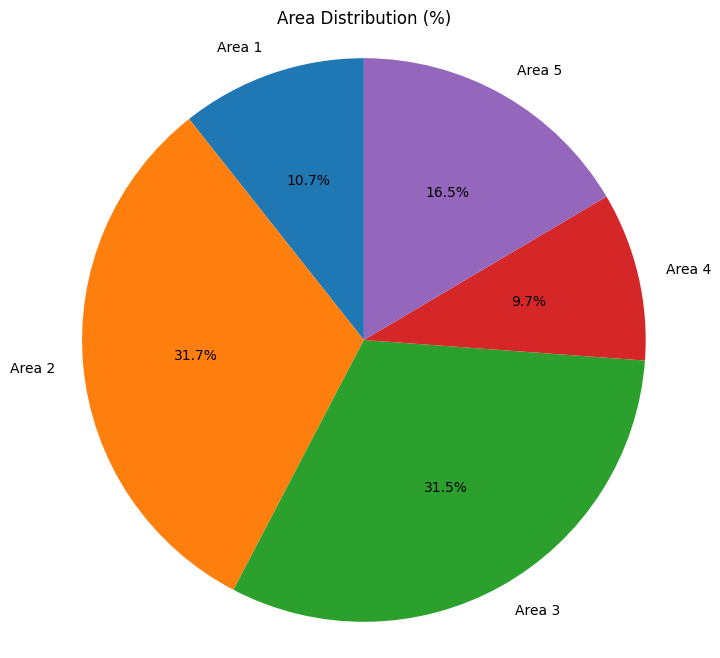

In [9]:
# labels for each slice
labels = [f'Area {i+1}' for i in range(len(areas_float))]
print(labels)

# plotting
plt.figure(figsize=(8, 8))
plt.pie(
    areas_float,
    labels=labels,
    autopct='%1.1f%%',  # this shows the percentage with 1 decimal place
    startangle=90      # rotate the start of the pie chart
)

plt.title('Area Distribution (%)')
plt.axis('equal')  # Equal aspect ratio makes the pie chart a circle.
plt.show()

**B) Make a new dataframe to add up the area and volume for the corresponding Family and Type for the different types of Walls to create an easy reading table.**

In [10]:
# reading file
url_walls = 'https://pennstateoffice365-my.sharepoint.com/:x:/g/personal/rjn5308_psu_edu/EbxsT8dwHKZMjusnoeR9DG8BZpc0QZYRGLcsQb44YxWK1A?e=DymvB6'
url_walls = url_walls + '&download=1'
r = requests.get(url_walls)

r.status_code
with open('walls.csv', 'w') as fid:
    fid.write(r.text)

walls_df = pd.read_csv("walls.csv")
print("size walls: ", len(walls_df))

# convert entire dataframe to string type
df_walls = walls_df.astype(str)

# extracting framing types
types_walls, areas_walls, volume_walls = [], [], []

for column in df_walls.columns:
    for cell in df_walls[column]:
      if "Family and Type :" in cell:
        type_wall = cell.split("Family and Type :")[1].strip()
        types_walls.append(type_wall)
      elif "Area :" in cell:
        area = cell.split("Area :")[1].strip()
        areas_walls.append(area)
      elif "Volume :" in cell:
        volume = cell.split("Volume :")[1].strip()
        volume_walls.append(volume)

print("size types:", len(types_walls))
print("size areas:", len(areas_walls))
print("size volume:", len(volume_walls))

print("areas: ", areas_walls)
print("volumes:", volume_walls)

# clean ' SF' from areas and convert to float
areas_walls_float = [float(area.replace('SF', '').strip()) for area in areas_walls]
print(areas_walls_float)

# clean ' CF' from volumes and convert to float
volume_walls_float = [float(volume.replace('CF', '').strip()) for volume in volume_walls]
print(volume_walls_float)

# Combine into a DataFrame
summary_df = pd.DataFrame({
    'Wall Type': types_walls,
    'Area (SF)': areas_walls_float,
    'Volume (CF)': volume_walls_float})

# Group by type and sum area and volume
wall_summary = summary_df.groupby('Wall Type').agg({'Area (SF)': 'sum','Volume (CF)': 'sum'}).reset_index()

# Display summary
print("\nWall Summary:")
print(wall_summary)

size walls:  37
size types: 37
size areas: 37
size volume: 37
areas:  ['750 SF', '52 SF', '186 SF', '552 SF', '186 SF', '50 SF', '839 SF', '554 SF', '228 SF', '178 SF', '37 SF', '11 SF', '68 SF', '75 SF', '34 SF', '81 SF', '185 SF', '17 SF', '27 SF', '69 SF', '94 SF', '333 SF', '405 SF', '391 SF', '377 SF', '518 SF', '524 SF', '509 SF', '57 SF', '1255 SF', '434 SF', '1129 SF', '30 SF', '440 SF', '1052 SF', '423 SF', '1025 SF']
volumes: ['1000.55 CF', '69.85 CF', '248.44 CF', '735.78 CF', '248.44 CF', '66.89 CF', '1118.00 CF', '738.56 CF', '328.08 CF', '112.84 CF', '23.59 CF', '7.27 CF', '43.49 CF', '47.44 CF', '21.60 CF', '51.39 CF', '117.62 CF', '10.87 CF', '16.94 CF', '44.05 CF', '59.48 CF', '211.46 CF', '269.87 CF', '260.72 CF', '251.57 CF', '329.33 CF', '332.85 CF', '323.69 CF', '36.01 CF', '797.48 CF', '275.78 CF', '717.62 CF', '18.85 CF', '279.38 CF', '668.25 CF', '268.48 CF', '651.34 CF']
[750.0, 52.0, 186.0, 552.0, 186.0, 50.0, 839.0, 554.0, 228.0, 178.0, 37.0, 11.0, 68.0, 75.0

In [11]:
# Reading file
url_walls = 'https://pennstateoffice365-my.sharepoint.com/:x:/g/personal/rjn5308_psu_edu/EbxsT8dwHKZMjusnoeR9DG8BZpc0QZYRGLcsQb44YxWK1A?e=DymvB6'
url_walls = url_walls + '&download=1'
r = requests.get(url_walls)

with open('walls.csv', 'w') as fid:
    fid.write(r.text)

walls_df = pd.read_csv("walls.csv")
print("size walls:", len(walls_df))

# Convert all data to strings
df_walls = walls_df.astype(str)

# Extract data row-by-row
types_walls, areas_walls, volume_walls = [], [], []

for _, row in df_walls.iterrows():
    wall_type, area, volume = None, None, None
    for cell in row:
        if "Family and Type :" in cell:
            wall_type = cell.split("Family and Type :")[1].strip()
        elif "Area :" in cell:
            area = cell.split("Area :")[1].replace("SF", "").strip()
        elif "Volume :" in cell:
            volume = cell.split("Volume :")[1].replace("CF", "").strip()

    # Only store if all three values are present
    if wall_type and area and volume:
        types_walls.append(wall_type)
        areas_walls.append(float(area))
        volume_walls.append(float(volume))

print("size types:", len(types_walls))
print("size areas:", len(areas_walls))
print("size volumes:", len(volume_walls))

# Combine into a DataFrame
summary_df = pd.DataFrame({
    'Wall Type': types_walls,
    'Area (SF)': areas_walls,
    'Volume (CF)': volume_walls
})

# Group by wall type
wall_summary = summary_df.groupby('Wall Type').agg({
    'Area (SF)': 'sum',
    'Volume (CF)': 'sum'
}).reset_index()

# Display result
print("\nWall Summary:")
print(wall_summary)

size walls: 37
size types: 37
size areas: 37
size volumes: 37

Wall Summary:
                               Wall Type  Area (SF)  Volume (CF)
0  Basic Wall: Foundation - 12" Concrete     3169.0      4226.51
1      Basic Wall: Generic - 16" Masonry      228.0       328.08
2               Basic Wall: Generic - 8"     1173.0       782.16
3       Basic Wall: Generic - 8" Masonry     8605.0      5467.10


##3) **BE CREATIVE.** You can create a code in Dynamo to edit the steam services, utilize the data in excel, or do something in Python with the data, etc. Even if you cannot complete what you want to do, please explain it fully what you are trying to accomplish for full credit.##
Some examples include (but certainly not limited to) editing the steam services building such as changing beams and columns sizes, creating drawing sheets, adding new structure to the building, and etc. with Dynamo coding. For excel, you can mess around with the spread sheet with using excel coding, create graphs and visuals, and etc. For python, you can utilize the CSV file to find new trends within the data, edit the data to export it in a different way, and etc.

Insert pictures and/or text here.

In [12]:
#insert python code here if you need to